In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Importing required libraries

In [2]:
%pip install deep-translator holidays pandas scikit-learn matplotlib seaborn pyarrow statsmodels pmdarima -q

import os
import gdown
import holidays

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from deep_translator import GoogleTranslator
from concurrent.futures import ThreadPoolExecutor, as_completed
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error

from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
import pmdarima as pm

# Warning
import warnings
warnings.filterwarnings('ignore')

# Visualization settings
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 5)

print("✓ SARIMA libraries imported")
print('✓ All libraries imported successfully')

Note: you may need to restart the kernel to use updated packages.
✓ SARIMA libraries imported
✓ All libraries imported successfully


# Helper Functions

In [3]:
def optimize_dataframe_memory(df_to_optimize, name="DataFrame"):
    """Optimize dataframe memory usage by downcasting types."""
    print(f"Original memory usage for {name}: {df_to_optimize.memory_usage(deep=True).sum() / (1024**2):.2f} MB")

    for col in df_to_optimize.columns:
        col_type = df_to_optimize[col].dtype

        if col_type == 'object':
            num_unique_values = len(df_to_optimize[col].unique())
            num_total_values = len(df_to_optimize[col])
            if num_unique_values / num_total_values < 0.5 and num_unique_values < 5000:
                df_to_optimize[col] = df_to_optimize[col].astype('category')
        elif 'int' in str(col_type):
            df_to_optimize[col] = pd.to_numeric(df_to_optimize[col], downcast='integer')
        elif 'float' in str(col_type):
            df_to_optimize[col] = pd.to_numeric(df_to_optimize[col], downcast='float')

    print(f"Optimized memory usage for {name}: {df_to_optimize.memory_usage(deep=True).sum() / (1024**2):.2f} MB")
    return df_to_optimize

def date_features(dataframe):
    """Extract date-based features."""
    dataframe["day"] = dataframe.date.dt.day
    dataframe["month"] = dataframe.date.dt.month
    dataframe["year"] = dataframe.date.dt.year
    dataframe['dayofweek'] = dataframe['date'].dt.dayofweek
    dataframe['week'] = dataframe['date'].dt.isocalendar().week
    return dataframe

def inspect_data(df, name="Dataset"):
    """
    Performs a comprehensive inspection of a dataframe.
    """
    print(f"--- Inspection Report for: {name} ---")
    print(f"Shape: {df.shape[0]} rows, {df.shape[1]} columns\n")

    # Create an info table
    info_df = pd.DataFrame({
        'Data Type': df.dtypes,
        'Unique Values': df.nunique(),
        'Missing Values': df.isnull().sum(),
        'Missing %': (df.isnull().sum() / len(df) * 100).round(2),
    })

    # Add memory usage
    memory_usage = df.memory_usage(deep=True).sum() / (1024**2)
    print(f"Memory Usage: {memory_usage:.2f} MB")

    print("\nColumn Statistics & Completeness:")
    display(info_df)

    # Preview statistical summary for numerical columns
    if not df.select_dtypes(include=[np.number]).empty:
        print("\nNumerical Summary:")
        display(df.describe(include='all'))

    print("\nFirst 5 Rows:")
    display(df.head())
    print("=" * 80)

In [4]:
# files = {
#     "sales.csv": "1skldI6u3iZFRi323HlVcpT_lTM9brI98",
#     "online.csv": "19mYW7hIeFxRSNal1uS9gPSWIKLQMO2zH",
#     "markdowns.csv": "1WqstN4-37D9P9rF37Bloy_U1gH0yL4AQ",
#     "price_history.csv": "1wm9NarRwwu6yJLLsnwczRrybOLq16Lw2",
#     "discounts_history.csv": "14EhYOVMlnPxPCXHVdXz4ZSabVS2ZZDLQ",
#     "actual_matrix.csv": "1jTxIQ_gEYqZbWVGdKgoAVKMslIuKEBea",
#     "catalog.csv": "1m60dC8nnRL2p9EJpQyM063OjeTfmQCP4",
#     "stores.csv": "19k_48mpTOrUTCUUSKurBu4VPdJiekeR_",
#     "test.csv": "1UlEFX581Rsmqdxi1rpNJRdY8lJBx2L8Y"
# }

# # Download files locally if not present
# for filename, file_id in files.items():
#     if not os.path.exists(filename):
#         url = f'https://drive.google.com/uc?id={file_id}'
#         print(f"Downloading {filename}...")
#         gdown.download(url, filename, quiet=False)

# df_sales = pd.read_csv("sales.csv", index_col=0, parse_dates=['date'])
# df_sales = optimize_dataframe_memory(df_sales, name="df_sales")

# df_online = pd.read_csv("online.csv", index_col=0, parse_dates=['date'])
# df_online = optimize_dataframe_memory(df_online, name="df_online")

# df_markdowns = pd.read_csv("markdowns.csv", index_col=0, parse_dates=['date'])
# df_price_history = pd.read_csv("price_history.csv", index_col=0, parse_dates=['date'])
# df_discounts_history = pd.read_csv("discounts_history.csv", index_col=0, parse_dates=['date'])
# df_actual_matrix = pd.read_csv("actual_matrix.csv", index_col=0, parse_dates=['date'])

# df_catalog = pd.read_csv("catalog.csv", index_col=0)
# df_catalog = optimize_dataframe_memory(df_catalog, name="df_catalog")

# df_stores = pd.read_csv("stores.csv", index_col=0)
# df_stores = optimize_dataframe_memory(df_stores, name="df_stores")

# df_test = pd.read_csv("test.csv", sep=";", index_col="row_id", parse_dates=['date'])

In [6]:
# Load into DataFrames
df_sales = pd.read_csv("sales.csv", index_col=0, parse_dates=['date'])
df_sales = optimize_dataframe_memory(df_sales, name="df_sales")

df_online = pd.read_csv("online.csv", index_col=0, parse_dates=['date'])
df_online = optimize_dataframe_memory(df_online, name="df_online")

df_catalog = pd.read_csv("catalog.csv", index_col=0)
df_catalog = optimize_dataframe_memory(df_catalog, name="df_catalog")

df_stores = pd.read_csv("stores.csv", index_col=0)
df_stores = optimize_dataframe_memory(df_stores, name="df_stores")

df_test = pd.read_csv("test.csv", sep=";", index_col="row_id", parse_dates=['date'])

print("\n✓ All datasets loaded successfully!")
print(f"Sales shape: {df_sales.shape}")
print(f"Online shape: {df_online.shape}")
print(f"Catalog shape: {df_catalog.shape}")
print(f"Stores shape: {df_stores.shape}")
print(f"Test shape: {df_test.shape}")

Original memory usage for df_sales: 772.63 MB
Optimized memory usage for df_sales: 694.66 MB
Original memory usage for df_online: 116.78 MB
Optimized memory usage for df_online: 100.71 MB
Original memory usage for df_catalog: 88.08 MB
Optimized memory usage for df_catalog: 23.47 MB
Original memory usage for df_stores: 0.00 MB
Optimized memory usage for df_stores: 0.00 MB

✓ All datasets loaded successfully!
Sales shape: (7432685, 6)
Online shape: (1123412, 6)
Catalog shape: (206161, 8)
Stores shape: (4, 5)
Test shape: (883680, 3)


# Data Cleaning & Merging

## Sales

In [7]:
# Inspecting sales data
inspect_data(df_sales, name="Sales Records")

# Clean sales data - filter first, then compute price to avoid inf/NaN
df_sales = df_sales.sort_values(["date", "item_id", "store_id"])

# Remove records with non-positive values BEFORE computing price_base
invalid_mask = (df_sales['quantity'] <= 0) | (df_sales['sum_total'] <= 0)
print(f"Removing {invalid_mask.sum()} invalid sales records")
df_sales = df_sales[~invalid_mask].copy()

# Now compute price_base (safe - no division by zero)
df_sales['price_base'] = df_sales['sum_total'] / df_sales['quantity']

print(f"✓ Sales data cleaned. Final shape: {df_sales.shape}")

--- Inspection Report for: Sales Records ---
Shape: 7432685 rows, 6 columns

Memory Usage: 694.66 MB

Column Statistics & Completeness:


,Data Type,Unique Values,Missing Values,Missing %
date,datetime64[ns],761,0,0.0
item_id,object,28182,0,0.0
quantity,float32,60209,0,0.0
price_base,float64,126497,0,0.0
sum_total,float64,471682,0,0.0
store_id,int8,4,0,0.0



Numerical Summary:


,date,item_id,quantity,price_base,sum_total,store_id
count,7432685,7432685,7.432685e+06,7.432685e+06,7.432685e+06,7.432685e+06
unique,NaN,28182,NaN,NaN,NaN,NaN
top,NaN,e5b2b6f57ea7,NaN,NaN,NaN,NaN
freq,NaN,2571,NaN,NaN,NaN,NaN
mean,2023-11-07 01:34:58.084933120,NaN,5.642400e+00,2.075824e+02,7.612796e+02,2.041405e+00
min,2022-08-28 00:00:00,NaN,-5.000000e+02,-2.167667e+04,-2.041080e+04,1.000000e+00
25%,2023-05-04 00:00:00,NaN,1.000000e+00,6.000000e+01,1.279000e+02,1.000000e+00
50%,2023-12-25 00:00:00,NaN,2.000000e+00,1.099000e+02,2.596000e+02,2.000000e+00
75%,2024-05-13 00:00:00,NaN,4.672000e+00,1.999000e+02,5.990000e+02,3.000000e+00
max,2024-09-26 00:00:00,NaN,4.952000e+03,2.899990e+04,6.865242e+05,4.000000e+00



First 5 Rows:


,date,item_id,quantity,price_base,sum_total,store_id
0,2023-08-04,293375605257,1.000,47.86,47.86,1
1,2023-08-04,a66fdf2c0ae7,3.000,49.60,148.80,1
2,2023-08-04,daa46ef49b7a,0.822,379.00,311.54,1
3,2023-08-04,a3b49c1bf758,1.000,129.00,129.00,1
4,2023-08-04,ab611c5cef62,7.000,79.90,559.30,1


Removing 9176 invalid sales records
✓ Sales data cleaned. Final shape: (7423509, 6)


In [8]:
# Inspecting online sales data
inspect_data(df_online, name="Online Sales Records")

# Clean online data - filter first, then compute price
df_online = df_online.sort_values(["date", "item_id", "store_id"])

# Remove records with non-positive values BEFORE computing price_base
invalid_mask = (df_online['quantity'] <= 0) | (df_online['sum_total'] <= 0)
print(f"Removing {invalid_mask.sum()} invalid online records")
df_online = df_online[~invalid_mask].copy()

# Now compute price_base (safe - no division by zero)
df_online['price_base'] = df_online['sum_total'] / df_online['quantity']

print(f"✓ Online data cleaned. Final shape: {df_online.shape}")

--- Inspection Report for: Online Sales Records ---
Shape: 1123412 rows, 6 columns

Memory Usage: 100.71 MB

Column Statistics & Completeness:


,Data Type,Unique Values,Missing Values,Missing %
date,datetime64[ns],761,0,0.0
item_id,object,18405,0,0.0
quantity,float32,15882,0,0.0
price_base,float32,73264,0,0.0
sum_total,float64,112454,0,0.0
store_id,int8,2,0,0.0



Numerical Summary:


,date,item_id,quantity,price_base,sum_total,store_id
count,1123412,1123412,1.123412e+06,1.123412e+06,1.123412e+06,1.123412e+06
unique,NaN,18405,NaN,NaN,NaN,NaN
top,NaN,a162df3be29c,NaN,NaN,NaN,NaN
freq,NaN,1047,NaN,NaN,NaN,NaN
mean,2023-10-25 13:29:06.836958976,NaN,2.194757e+00,1.497957e+02,2.259123e+02,1.659448e+00
min,2022-08-28 00:00:00,NaN,2.000000e-03,-8.458330e+03,-3.418800e+02,1.000000e+00
25%,2023-03-25 00:00:00,NaN,1.000000e+00,4.334000e+01,6.148000e+01,1.000000e+00
50%,2023-12-19 00:00:00,NaN,1.000000e+00,7.869500e+01,1.109600e+02,1.000000e+00
75%,2024-05-09 00:00:00,NaN,2.000000e+00,1.692625e+02,2.229000e+02,1.000000e+00
max,2024-09-26 00:00:00,NaN,9.990000e+02,1.217162e+04,4.355644e+04,4.000000e+00



First 5 Rows:


,date,item_id,quantity,price_base,sum_total,store_id
0,2023-08-04,4aa8dbe05246,3.0,12.400000,37.21,1
1,2023-08-04,4e0fbcf99cf9,2.0,56.270000,112.54,1
2,2023-08-04,2e008b673129,2.0,56.270000,112.54,1
3,2023-08-04,49db9c973903,1.0,29.940001,29.94,1
4,2023-08-04,9d6072422e8e,1.0,80.099998,80.10,1


Removing 6 invalid online records
✓ Online data cleaned. Final shape: (1123406, 6)


## Online Sales

In [9]:
# Merge sales and online data
df_online = df_online.rename(columns={
    "price_base": "price_base_online",
    "sum_total": "sum_total_online",
    "quantity": "quantity_online"
})
df_online["online"] = True

df_sales = df_sales.rename(columns={
    "quantity": "quantity_sales",
    "price_base": "price_base_sales",
    "sum_total": "sum_total_sales"
})

# Perform outer merge
df = pd.merge(df_sales, df_online[['date', 'item_id', 'store_id', 'quantity_online', 'price_base_online', 'sum_total_online', 'online']],
             on=['date', 'item_id', 'store_id'], how='outer')

# Fill NaN values
df['quantity_sales'] = df['quantity_sales'].fillna(0)
df['quantity_online'] = df['quantity_online'].fillna(0)
df['quantity'] = df['quantity_sales'] + df['quantity_online']
df['online'] = df['online'].fillna(False)

df['price_base_sales'] = df['price_base_sales'].fillna(0)
df['sum_total_sales'] = df['sum_total_sales'].fillna(0)
df['price_base_online'] = df['price_base_online'].fillna(0)
df['sum_total_online'] = df['sum_total_online'].fillna(0)

df['price_base'] = df.apply(lambda row: row['price_base_sales'] if row['price_base_sales'] > 0 else row['price_base_online'], axis=1)
df['sum_total'] = df.apply(lambda row: row['sum_total_sales'] if row['sum_total_sales'] > 0 else row['sum_total_online'], axis=1)

final_columns = ['date', 'item_id', 'store_id', 'quantity', 'price_base', 'sum_total', 'online',
                'quantity_online', 'price_base_online', 'sum_total_online']
df = df[final_columns]
df = optimize_dataframe_memory(df, name="df after sales/online merge")

print(f"✓ Sales and online merged. Final shape: {df.shape}")

Original memory usage for df after sales/online merge: 808.83 MB
Optimized memory usage for df after sales/online merge: 750.54 MB
✓ Sales and online merged. Final shape: (7640752, 10)


## Date Range

In [10]:
# Check the date range in the merged dataframe
date_min = df['date'].min()
date_max = df['date'].max()
duration = date_max - date_min

print(f"Start Date: {date_min}")
print(f"End Date:   {date_max}")
print(f"Total Duration: {duration.days} days")

Start Date: 2022-08-28 00:00:00
End Date:   2024-09-26 00:00:00
Total Duration: 760 days


In [11]:
# 1. Capture the initial row count
rows_before = len(df)

# 2. Filter the dataframe to start from 2023-09-26
df = df[df['date'] >= '2023-09-26'].copy()

# 3. Capture the new row count
rows_after = len(df)
rows_removed = rows_before - rows_after

# 4. Verify the new date range and row change
print(f"New Start Date: {df['date'].min()}")
print(f"New End Date:   {df['date'].max()}")
print(f"---")
print(f"Rows before:    {rows_before:,}")
print(f"Rows after:     {rows_after:,}")
print(f"Rows removed:   {rows_removed:,}")

New Start Date: 2023-09-26 00:00:00
New End Date:   2024-09-26 00:00:00
---
Rows before:    7,640,752
Rows after:     4,592,221
Rows removed:   3,048,531


In [12]:
# Check the date range in the test dataframe
date_min = df_test['date'].min()
date_max = df_test['date'].max()
duration = date_max - date_min

print(f"Start Date: {date_min}")
print(f"End Date:   {date_max}")
print(f"Total Duration: {duration.days} days")

Start Date: 2024-09-27 00:00:00
End Date:   2024-10-26 00:00:00
Total Duration: 29 days


## Stores

In [13]:
# Merge with stores data
df = df.merge(df_stores, how='left', left_on=["store_id"], right_on=["store_id"])
df = optimize_dataframe_memory(df, name="df after stores merge")

print(f"✓ Stores data merged. Final shape: {df.shape}")

Original memory usage for df after stores merge: 1181.11 MB
Optimized memory usage for df after stores merge: 472.99 MB
✓ Stores data merged. Final shape: (4592221, 14)


## Catalog

In [14]:
# Clean catalog data
COLUMNS_TO_TRANSLATE = ["dept_name", "class_name", "subclass_name", "item_type"]
MAX_WORKERS = 20

def translate_value(val):
    try:
        return val, GoogleTranslator(source="ru", target="en").translate(str(val))
    except:
        return val, val

for col in COLUMNS_TO_TRANSLATE:
    unique_vals = df_catalog[col].dropna().unique().tolist()
    print(f"Translating {col}: {len(unique_vals)} unique values...")

    translation_map = {}
    with ThreadPoolExecutor(max_workers=MAX_WORKERS) as executor:
        futures = {executor.submit(translate_value, val): val for val in unique_vals}
        for future in as_completed(futures):
            original, translated = future.result()
            translation_map[original] = translated

    df_catalog[col] = df_catalog[col].map(translation_map)

# df_catalog['item_type'] = df_catalog['item_type'].fillna("other")
df_catalog.drop(columns=['item_type','fatness', 'weight_volume', 'weight_netto'], inplace=True)

# Clean text
categorical_cols = ['dept_name', 'class_name', 'subclass_name']
for col in categorical_cols:
    if col in df_catalog.columns:
        df_catalog[col] = df_catalog[col].str.strip().str.lower()

df_catalog = optimize_dataframe_memory(df_catalog, name="df_catalog after cleaning")
print(f"✓ Catalog cleaned")

Translating dept_name: 197 unique values...
Translating class_name: 613 unique values...
Translating subclass_name: 1007 unique values...
Translating item_type: 669 unique values...
Original memory usage for df_catalog after cleaning: 63.83 MB
Optimized memory usage for df_catalog after cleaning: 28.64 MB
✓ Catalog cleaned


In [15]:
# Merge with catalog data
df = df.merge(df_catalog, how='left', left_on=["item_id"], right_on=["item_id"])

# Intelligent missing value handling (don't just drop rows)
print(f"Missing values by column:")
missing_info = df.isnull().sum()
print(missing_info[missing_info > 0])

# Fill categorical nulls with 'unknown' (safer than dropping)
categorical_cols_to_fill = ['dept_name', 'class_name', 'subclass_name', 'item_type', 'format', 'division']
for col in categorical_cols_to_fill:
    if col in df.columns and df[col].isnull().sum() > 0:
        # Convert categorical to string to allow filling with 'unknown'
        if df[col].dtype.name == 'category':
            df[col] = df[col].astype(str).replace('nan', 'unknown')
        else:
            df[col].fillna('unknown', inplace=True)
        print(f"  Filled {df[col].isnull().sum()} nulls in {col} with 'unknown'")

# Drop only rows where price_base or sum_total are still null (rare data quality issues)
rows_before = len(df)
df.dropna(subset=['price_base', 'sum_total', 'quantity'], inplace=True)
rows_after = len(df)
print(f"✓ Removed {rows_before - rows_after} rows with null price/quantity data. Final shape: {df.shape}")

# Optimize memory after all fixes
df = optimize_dataframe_memory(df, name="df after catalog merge and cleanup")

Missing values by column:
dept_name        179113
class_name       179113
subclass_name    179113
dtype: int64
  Filled 0 nulls in dept_name with 'unknown'
  Filled 0 nulls in class_name with 'unknown'
  Filled 0 nulls in subclass_name with 'unknown'
✓ Removed 0 rows with null price/quantity data. Final shape: (4592221, 17)
Original memory usage for df after catalog merge and cleanup: 1276.90 MB
Optimized memory usage for df after catalog merge and cleanup: 499.38 MB


# Feature Engineering

## Dates

In [16]:
# Add date features
df = date_features(df)
df = optimize_dataframe_memory(df, name="df after date features")

print(f"✓ Date features created")

Original memory usage for df after date features: 591.35 MB
Optimized memory usage for df after date features: 543.18 MB
✓ Date features created


In [17]:
df

,date,item_id,store_id,quantity,price_base,sum_total,online,quantity_online,price_base_online,sum_total_online,...,city,area,dept_name,class_name,subclass_name,day,month,year,dayofweek,week
0,2023-09-26,001829cb707d,1,2.000,159.899994,319.80,False,0.000,0.000000,0.00,...,City1,1500,cream,cream,drinking cream,26,9,2023,1,39
1,2023-09-26,001829cb707d,2,2.000,159.899994,319.80,False,0.000,0.000000,0.00,...,City1,210,cream,cream,drinking cream,26,9,2023,1,39
2,2023-09-26,001b302a9387,1,3.000,79.900002,239.70,False,0.000,0.000000,0.00,...,City1,1500,"ketchups, tomato-based sauces",ketchups,soft packaging,26,9,2023,1,39
3,2023-09-26,001dadca6678,1,1.707,729.904419,1069.31,True,0.242,333.966949,80.82,...,City1,1500,frozen berries,forest,weight,26,9,2023,1,39
4,2023-09-26,0022b986c8f0,1,1.000,52.900002,52.90,False,0.000,0.000000,0.00,...,City1,1500,"spices, seasoning",monospecies,monospecies,26,9,2023,1,39
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4592216,2024-09-26,ffea55e3589f,1,0.760,499.894745,379.92,False,0.000,0.000000,0.00,...,City1,1500,candies,chocolate candies,chocolate candies by weight,26,9,2024,3,39
4592217,2024-09-26,ffea55e3589f,2,0.105,719.142883,75.51,False,0.000,0.000000,0.00,...,City1,210,candies,chocolate candies,chocolate candies by weight,26,9,2024,3,39
4592218,2024-09-26,ffea55e3589f,4,0.499,499.899780,249.45,False,0.000,0.000000,0.00,...,City3,1887,candies,chocolate candies,chocolate candies by weight,26,9,2024,3,39
4592219,2024-09-26,fffb04d8e873,1,4.000,103.970001,415.88,False,0.000,0.000000,0.00,...,City1,1500,frozen vegetables,mono vegetables,packed,26,9,2024,3,39


## Holidays

In [18]:
def add_holidays(dataframe, country='RU'):
    years = range(dataframe['date'].min().year, dataframe['date'].max().year + 1)
    country_holidays = holidays.CountryHoliday(country, years=years)
    dataframe['is_holiday'] = dataframe['date'].dt.date.isin(country_holidays.keys()).astype(int)
    print(f"Processed {country} holidays. Found {dataframe['is_holiday'].sum()} holiday records.")
    return dataframe

df = add_holidays(df)

Processed RU holidays. Found 222752 holiday records.


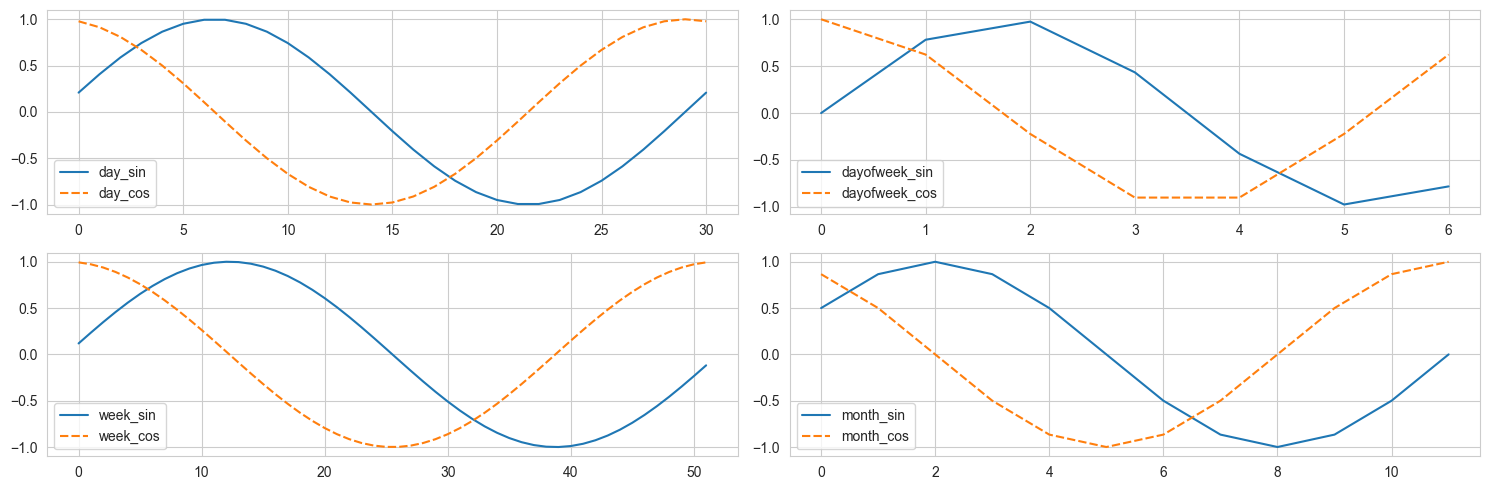

In [19]:
# Cyclical encoding for day
df['day_sin'] = np.sin(2 * np.pi * df['day']/30)
df['day_cos'] = np.cos(2 * np.pi * df['day']/30)

# Cyclical encoding for month
df['month_sin'] = np.sin(2 * np.pi * df['month']/12)
df['month_cos'] = np.cos(2 * np.pi * df['month']/12)

# Cyclical encoding for week
df['week_sin'] = np.sin(2 * np.pi * df['week']/53)
df['week_cos'] = np.cos(2 * np.pi * df['week']/53)

# Cyclical encoding for dayofweek (like month)
df['dayofweek_sin'] = np.sin(2* np.pi * df['dayofweek']/7)
df['dayofweek_cos'] = np.cos(2* np.pi * df['dayofweek']/7)

plt.subplots(2, 2, figsize=(15, 5))
for i, col in enumerate(["day", "dayofweek", "week", "month"]):
    aux = df.groupby([col, col+"_sin", col+"_cos"]).quantity.mean().reset_index()
    aux[col] = aux[col].apply(str)
    plt.subplot(2, 2, i+1)
    sns.lineplot(data=aux[[col+"_sin", col+"_cos"]])
plt.tight_layout()

## Rolling Averages

In [20]:
# Add rolling average features
df = df.sort_values(by=['item_id', 'store_id', 'date'])

windows = [7, 14, 30]
for window in windows:
    df[f'rolling_avg_quantity_w{window}'] = df.groupby(['item_id', 'store_id'])['quantity']\
                                            .transform(lambda x: x.rolling(window=window, closed='left').mean())

rolling_cols = [f'rolling_avg_quantity_w{window}' for window in windows]
# Use forward-fill for missing values (more honest than 0), then backfill extremes
df[rolling_cols] = df.groupby(['item_id', 'store_id'])[rolling_cols].transform(lambda x: x.fillna(method='bfill').fillna(0))
df = optimize_dataframe_memory(df, name="df after rolling features")

print(f"✓ Rolling average features created for windows: {windows}")

Original memory usage for df after rolling features: 1007.40 MB
Optimized memory usage for df after rolling features: 819.08 MB
✓ Rolling average features created for windows: [7, 14, 30]


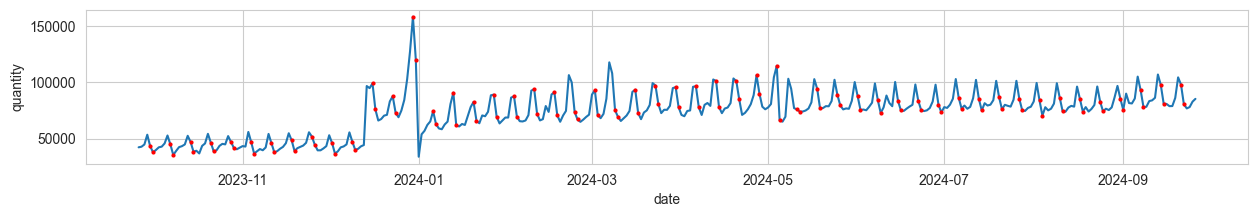

In [21]:
# Add advanced date and seasonal features
df['day_of_year'] = df['date'].dt.dayofyear
df['days_since_start'] = (df['date'] - df['date'].min()).dt.days  # Linear trend
df['is_month_start'] = (df['date'].dt.day <= 3).astype(int)
df['is_month_end'] = (df['date'].dt.day >= 28).astype(int)

# Payday indicators (often strong for consumer goods)
df['is_payday_near'] = ((df['date'].dt.day >= 23) | (df['date'].dt.day <= 5)).astype(int)

df["season"] = 0
df.loc[(df.month == 4) | (df.month == 5), "season"] = 1
df.loc[(df.month >= 6) & (df.month <= 8), "season"] = 2
df.loc[(df.month == 9) | (df.month == 10), "season"] = 3
df.loc[((df.month >= 1) & (df.month <= 3)) | (df.month == 11) | (df.month == 12), "season"] = 4

# Add additional calendar features
df['quarter'] = df['date'].dt.quarter
df['is_weekend'] = (df['dayofweek'] >= 5).astype(int)

plt.figure(figsize=(15, 2))
aux = df.groupby(["date", "is_weekend"]).quantity.sum().reset_index()
sns.lineplot(data=aux, x="date", y="quantity");
aux2 = aux.loc[aux["is_weekend"] == True, ["date", "quantity"]]
plt.plot(aux2.date, aux2.quantity, "ro", markersize=2);

In [22]:
# Add lag features (crucial for time series - past values are strongest predictors)
df = df.sort_values(by=['item_id', 'store_id', 'date'])

print("Creating lag features (7, 14, 28, 365 days)...")
lags = [7, 14, 28, 365]
for lag in lags:
    df[f'lag_{lag}_quantity'] = df.groupby(['item_id', 'store_id'])['quantity'].shift(lag)
    # Forward-fill within group for missing values (e.g., new products)
    df[f'lag_{lag}_quantity'] = df.groupby(['item_id', 'store_id'])[f'lag_{lag}_quantity'].transform(
        lambda x: x.fillna(method='bfill')
    ).fillna(0)

print(f"✓ Lag features created for windows: {lags}")

Creating lag features (7, 14, 28, 365 days)...
✓ Lag features created for windows: [7, 14, 28, 365]


In [23]:
print(f"✓ Additional features created")
print(f"\nFinal feature set shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")

✓ Additional features created

Final feature set shape: (4592221, 46)
Columns: ['date', 'item_id', 'store_id', 'quantity', 'price_base', 'sum_total', 'online', 'quantity_online', 'price_base_online', 'sum_total_online', 'division', 'format', 'city', 'area', 'dept_name', 'class_name', 'subclass_name', 'day', 'month', 'year', 'dayofweek', 'week', 'is_holiday', 'day_sin', 'day_cos', 'month_sin', 'month_cos', 'week_sin', 'week_cos', 'dayofweek_sin', 'dayofweek_cos', 'rolling_avg_quantity_w7', 'rolling_avg_quantity_w14', 'rolling_avg_quantity_w30', 'day_of_year', 'days_since_start', 'is_month_start', 'is_month_end', 'is_payday_near', 'season', 'quarter', 'is_weekend', 'lag_7_quantity', 'lag_14_quantity', 'lag_28_quantity', 'lag_365_quantity']


In [24]:
display(df)

,date,item_id,store_id,quantity,price_base,sum_total,online,quantity_online,price_base_online,sum_total_online,...,is_month_start,is_month_end,is_payday_near,season,quarter,is_weekend,lag_7_quantity,lag_14_quantity,lag_28_quantity,lag_365_quantity
0,2023-09-26,001829cb707d,1,2.000,159.899994,319.80,False,0.000,0.000000,0.00,...,0,0,1,3,3,0,2.0,2.0,2.0,0.0
15543,2023-09-28,001829cb707d,1,3.000,159.899994,479.70,False,0.000,0.000000,0.00,...,0,1,1,3,3,0,2.0,2.0,2.0,0.0
23404,2023-09-29,001829cb707d,1,1.000,159.899994,159.90,False,0.000,0.000000,0.00,...,0,1,1,3,3,0,2.0,2.0,2.0,0.0
32005,2023-09-30,001829cb707d,1,1.000,159.899994,159.90,False,0.000,0.000000,0.00,...,0,1,1,3,3,1,2.0,2.0,2.0,0.0
39956,2023-10-01,001829cb707d,1,2.000,159.899994,319.80,False,0.000,0.000000,0.00,...,1,0,1,3,4,1,2.0,2.0,2.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3726849,2024-07-26,fffddcc5521e,1,0.800,296.687500,237.35,True,0.800,296.687500,237.35,...,0,0,1,2,3,0,0.0,0.0,0.0,0.0
3740948,2024-07-27,fffddcc5521e,1,0.516,219.224823,113.12,True,0.516,219.224823,113.12,...,0,0,1,2,3,1,0.0,0.0,0.0,0.0
3851842,2024-08-04,fffddcc5521e,1,0.402,284.502472,114.37,True,0.402,284.502472,114.37,...,0,0,1,2,3,1,0.0,0.0,0.0,0.0
3865675,2024-08-05,fffddcc5521e,1,0.358,178.631287,63.95,True,0.358,178.631287,63.95,...,0,0,1,2,3,0,0.0,0.0,0.0,0.0


# SARIMA

## Prepare the Time Series

In [25]:
# ─── Option A: Aggregate all stores & items (macro-level forecast) ───
# ts = (
#     df.groupby('date')['quantity']
#       .sum()
#       .asfreq('D')          # ensure daily frequency
#       .fillna(0)            # fill missing dates with 0
#       .rename('total_quantity')
# )

# ─── Option B: Pick a single store-item pair (micro-level forecast) ───
# Uncomment and set your IDs below
ITEM_ID  = df['item_id'].value_counts().index[0]   # most frequent item
STORE_ID = df['store_id'].value_counts().index[0]  # most frequent store
ts = (
    df[(df['item_id'] == ITEM_ID) & (df['store_id'] == STORE_ID)]
      .set_index('date')['quantity']
      .asfreq('D')
      .fillna(0)
      .rename('quantity')
)
print(f"Series: item={ITEM_ID}, store={STORE_ID}")

print(f"Time series shape : {ts.shape}")
print(f"Date range        : {ts.index.min()} → {ts.index.max()}")
print(f"Missing dates     : {ts.isna().sum()}")
ts.tail()

Series: item=9a7e315f3f42, store=1
Time series shape : (367,)
Date range        : 2023-09-26 00:00:00 → 2024-09-26 00:00:00
Missing dates     : 0


date
2024-09-22    295.708008
2024-09-23    288.088013
2024-09-24    306.431000
2024-09-25    303.735992
2024-09-26    330.194000
Freq: D, Name: quantity, dtype: float32

## Visualize & Stationarity Tests

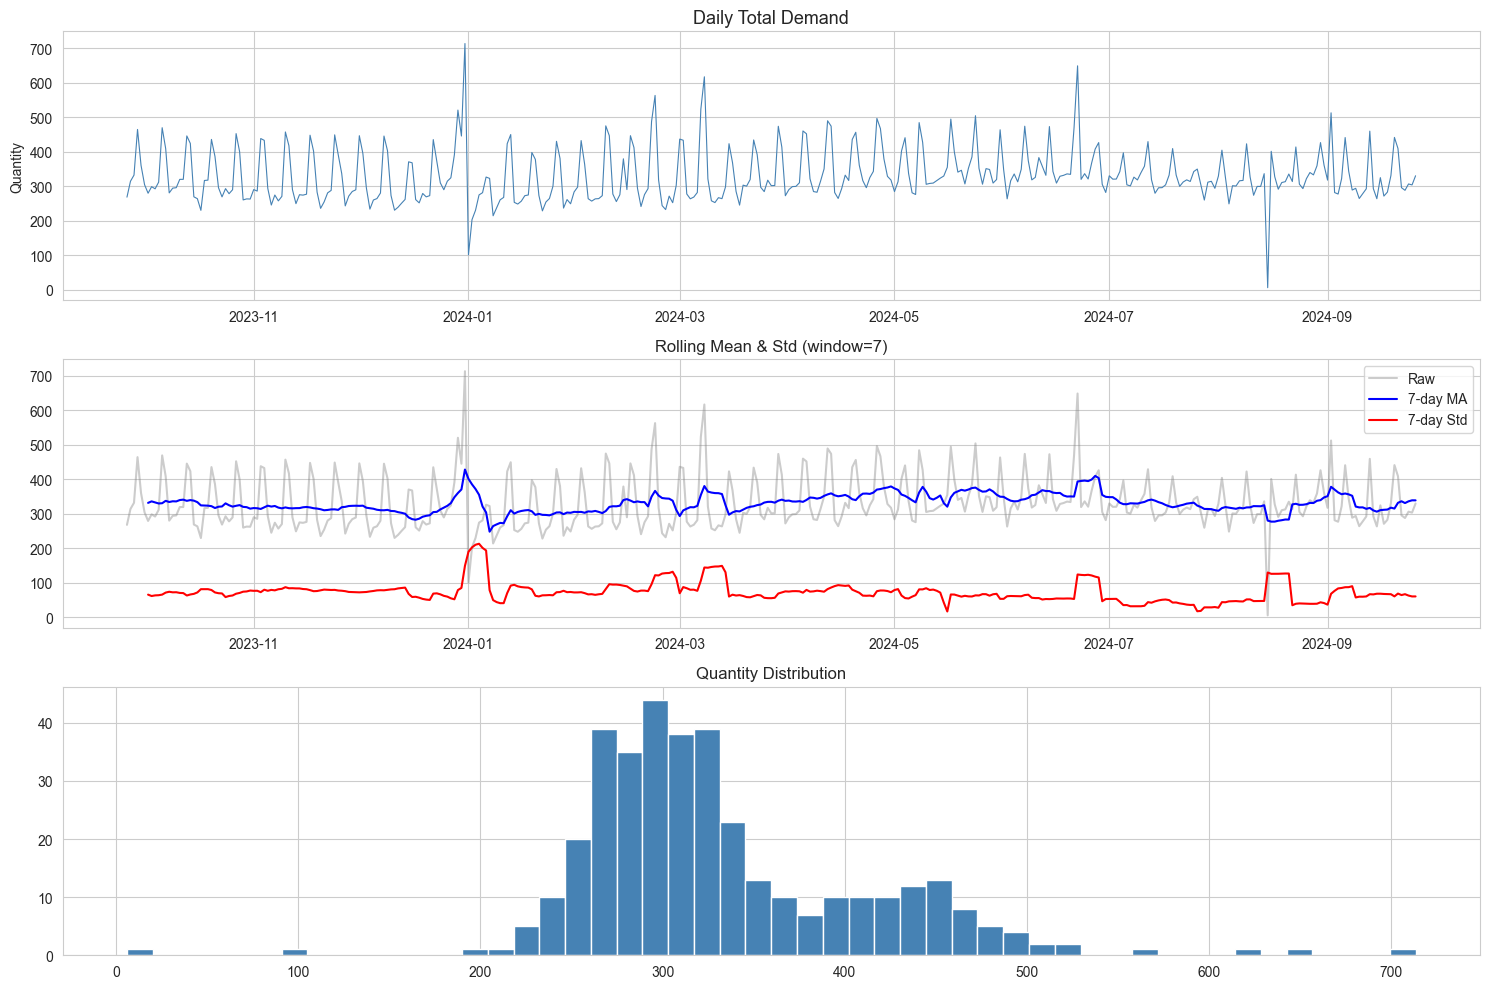


── ADF Test ──
  Statistic : -3.0911
  p-value   : 0.0272
  → Series is STATIONARY ✓

── KPSS Test ──
  Statistic : 0.5035
  p-value   : 0.0409
  → Series is NON-STATIONARY ✗


In [26]:
fig, axes = plt.subplots(3, 1, figsize=(15, 10))

# Raw series
axes[0].plot(ts, color='steelblue', linewidth=0.8)
axes[0].set_title('Daily Total Demand', fontsize=13)
axes[0].set_ylabel('Quantity')

# 7-day rolling mean & std
roll = ts.rolling(7)
axes[1].plot(ts, alpha=0.4, color='gray', label='Raw')
axes[1].plot(roll.mean(), color='blue', label='7-day MA')
axes[1].plot(roll.std(),  color='red',  label='7-day Std')
axes[1].set_title('Rolling Mean & Std (window=7)')
axes[1].legend()

# Histogram
axes[2].hist(ts, bins=50, color='steelblue', edgecolor='white')
axes[2].set_title('Quantity Distribution')
plt.tight_layout()
plt.show()

# ── ADF Test (null = non-stationary) ──
adf_result = adfuller(ts.dropna())
print("\n── ADF Test ──")
print(f"  Statistic : {adf_result[0]:.4f}")
print(f"  p-value   : {adf_result[1]:.4f}")
print(f"  → Series is {'STATIONARY ✓' if adf_result[1] < 0.05 else 'NON-STATIONARY ✗ (differencing needed)'}")

# ── KPSS Test (null = stationary) ──
kpss_result = kpss(ts.dropna(), regression='c', nlags='auto')
print("\n── KPSS Test ──")
print(f"  Statistic : {kpss_result[0]:.4f}")
print(f"  p-value   : {kpss_result[1]:.4f}")
print(f"  → Series is {'STATIONARY ✓' if kpss_result[1] > 0.05 else 'NON-STATIONARY ✗'}")

## ACF / PACF Plots (manual order selection)

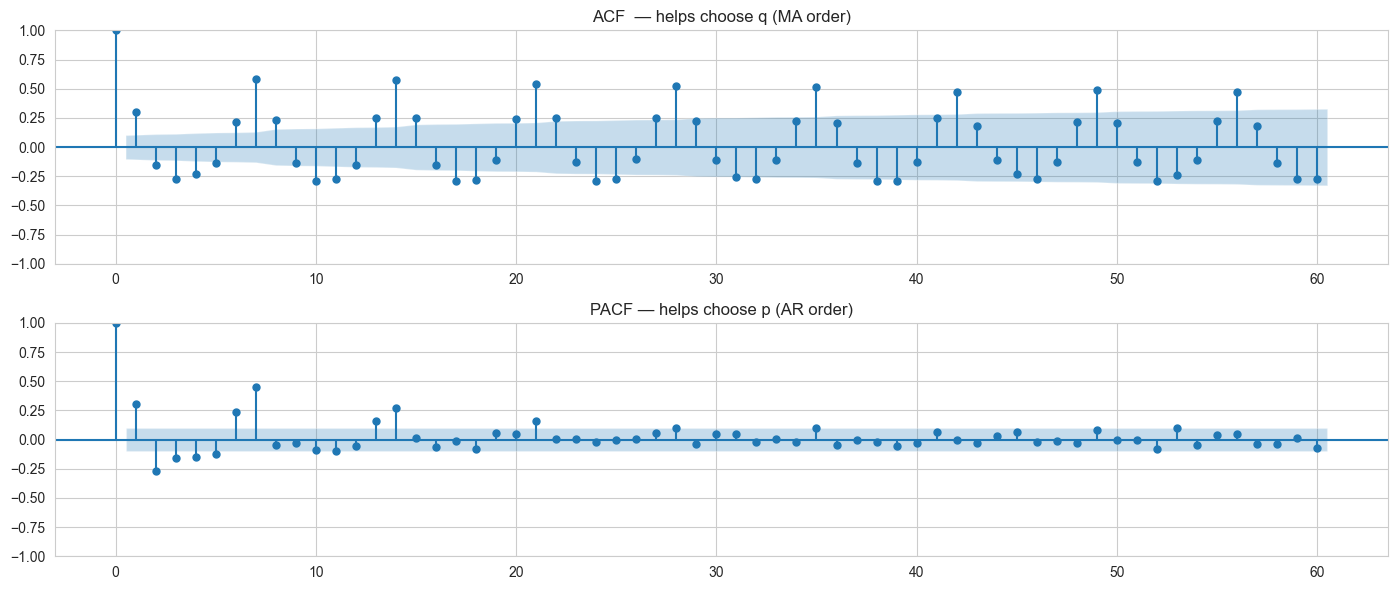

In [27]:
fig, axes = plt.subplots(2, 1, figsize=(14, 6))
plot_acf(ts.dropna(),  lags=60, ax=axes[0], title='ACF  — helps choose q (MA order)')
plot_pacf(ts.dropna(), lags=60, ax=axes[1], title='PACF — helps choose p (AR order)')
plt.tight_layout()
plt.show()

# Rule of thumb:
#  - PACF cuts off at lag p  → AR(p)
#  - ACF  cuts off at lag q  → MA(q)
#  - Both tail off           → ARMA(p, q)
#  - Seasonal spikes at multiples of 7 → weekly seasonality (s=7)

## Auto-select SARIMA Orders with `auto_arima`

In [28]:
# auto_arima searches over (p,d,q) x (P,D,Q,s) and picks by AIC
# s=7 for weekly seasonality; change to 30 for monthly
print("Running auto_arima (this may take 1–3 min)...")

auto_model = pm.auto_arima(
    ts,
    start_p=1, start_q=1,
    max_p=3,   max_q=3,
    d=None,            # auto-detect differencing order
    seasonal=True,
    m=7,               # weekly seasonality (s=7); try m=30 for monthly
    start_P=0, start_Q=0,
    max_P=2,   max_Q=2,
    D=1,               # seasonal differencing order
    information_criterion='aic',
    stepwise=True,
    suppress_warnings=True,
    error_action='ignore',
    trace=True
)

print(f"\n✓ Best order   : ARIMA{auto_model.order}")
print(f"✓ Seasonal     : {auto_model.seasonal_order}")
print(f"✓ AIC          : {auto_model.aic():.2f}")
auto_model.summary()

Running auto_arima (this may take 1–3 min)...
Performing stepwise search to minimize aic
 ARIMA(1,0,1)(0,1,0)[7] intercept   : AIC=4078.306, Time=0.36 sec
 ARIMA(0,0,0)(0,1,0)[7] intercept   : AIC=4087.181, Time=0.04 sec
 ARIMA(1,0,0)(1,1,0)[7] intercept   : AIC=3978.303, Time=0.41 sec
 ARIMA(0,0,1)(0,1,1)[7] intercept   : AIC=3895.040, Time=0.71 sec
 ARIMA(0,0,0)(0,1,0)[7]             : AIC=4085.182, Time=0.02 sec
 ARIMA(0,0,1)(0,1,0)[7] intercept   : AIC=4076.348, Time=0.18 sec
 ARIMA(0,0,1)(1,1,1)[7] intercept   : AIC=3896.411, Time=1.04 sec
 ARIMA(0,0,1)(0,1,2)[7] intercept   : AIC=3896.485, Time=1.78 sec
 ARIMA(0,0,1)(1,1,0)[7] intercept   : AIC=3978.301, Time=0.46 sec
 ARIMA(0,0,1)(1,1,2)[7] intercept   : AIC=3898.856, Time=1.34 sec
 ARIMA(0,0,0)(0,1,1)[7] intercept   : AIC=3905.435, Time=0.24 sec
 ARIMA(1,0,1)(0,1,1)[7] intercept   : AIC=3897.021, Time=0.69 sec
 ARIMA(0,0,2)(0,1,1)[7] intercept   : AIC=3897.020, Time=0.96 sec
 ARIMA(1,0,0)(0,1,1)[7] intercept   : AIC=3895.690, T

<class 'statsmodels.iolib.summary.Summary'>
"""
                                     SARIMAX Results                                     
=========================================================================================
Dep. Variable:                                 y   No. Observations:                  367
Model:             SARIMAX(0, 0, 1)x(0, 1, 1, 7)   Log Likelihood               -1943.580
Date:                           Tue, 28 Apr 2026   AIC                           3893.160
Time:                                   22:08:45   BIC                           3904.819
Sample:                               09-26-2023   HQIC                          3897.796
                                    - 09-26-2024                                         
Covariance Type:                             opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1          0.1912      0.026      7.447      0.000       0.141       0.241
ma.S.L7       -0.8623      0.033    -25.973      0.000      -0.927      -0.797
sigma2      2788.8696     65.621     42.499      0.000    2660.254    2917.485
===================================================================================
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):              5167.40
Prob(Q):                              0.98   Prob(JB):                         0.00
Heteroskedasticity (H):               0.98   Skew:                             1.11
Prob(H) (two-sided):                  0.91   Kurtosis:                        21.43
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

## Train / Test Split & Fit SARIMA

In [29]:
# ── Split: last 28 days as hold-out test ──
TEST_DAYS = 28
train = ts[:-TEST_DAYS]
test  = ts[-TEST_DAYS:]

print(f"Train: {train.index[0].date()} → {train.index[-1].date()}  ({len(train)} days)")
print(f"Test : {test.index[0].date()} → {test.index[-1].date()}   ({len(test)} days)")

# ── Fit using the best order found above ──
order          = auto_model.order
seasonal_order = auto_model.seasonal_order

sarima_model = SARIMAX(
    train,
    order=order,
    seasonal_order=seasonal_order,
    enforce_stationarity=False,
    enforce_invertibility=False
)

result = sarima_model.fit(disp=False, maxiter=200)
print(result.summary())

Train: 2023-09-26 → 2024-08-29  (339 days)
Test : 2024-08-30 → 2024-09-26   (28 days)
                                     SARIMAX Results                                     
Dep. Variable:                          quantity   No. Observations:                  339
Model:             SARIMAX(0, 0, 1)x(0, 1, 1, 7)   Log Likelihood               -1748.167
Date:                           Tue, 28 Apr 2026   AIC                           3502.335
Time:                                   22:08:46   BIC                           3513.668
Sample:                               09-26-2023   HQIC                          3506.859
                                    - 08-29-2024                                         
Covariance Type:                             opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1          0.1948      0.027    

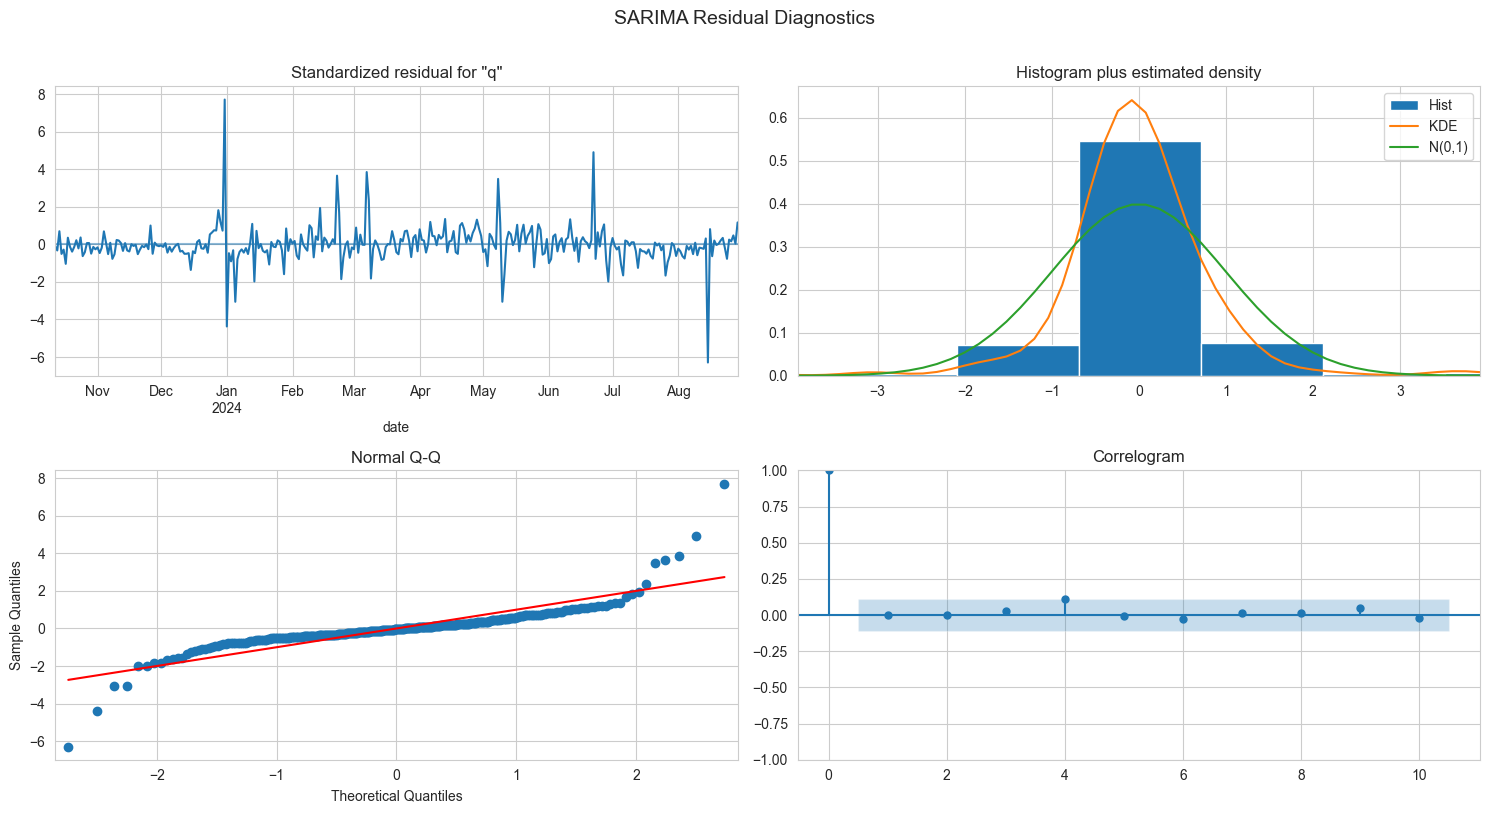


Ljung-Box Test:
       lb_stat     lb_pvalue
10  143.702622  7.335168e-26
20  145.812629  3.968358e-21
→ Good fit if all p-values > 0.05 (residuals are white noise)


In [30]:
result.plot_diagnostics(figsize=(15, 8))
plt.suptitle('SARIMA Residual Diagnostics', y=1.01, fontsize=14)
plt.tight_layout()
plt.show()

# Ljung-Box test (null = residuals are white noise; want p > 0.05)
lb = acorr_ljungbox(result.resid, lags=[10, 20], return_df=True)
print("\nLjung-Box Test:")
print(lb)
print("→ Good fit if all p-values > 0.05 (residuals are white noise)")

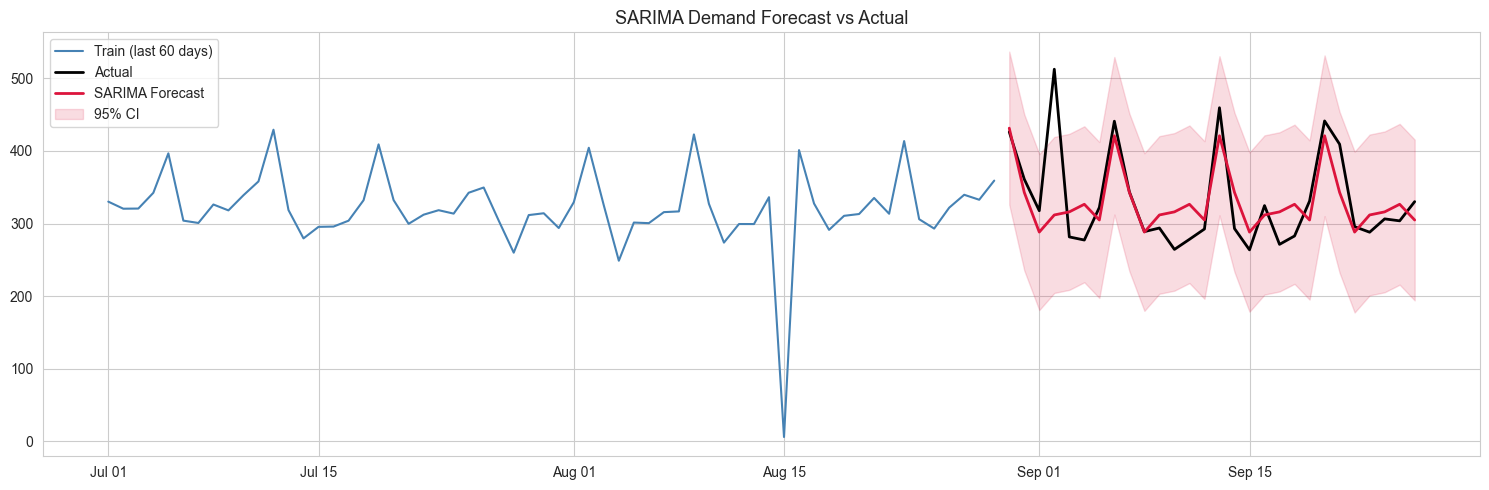


── Forecast Evaluation (Test Set) ──
  MAE   : 32.94
  RMSE  : 49.04
  MAPE  : 9.67%
  SMAPE : 9.76%


In [31]:
# ── One-shot forecast over test horizon ──
forecast_obj = result.get_forecast(steps=TEST_DAYS)
forecast_mean = forecast_obj.predicted_mean
conf_int      = forecast_obj.conf_int(alpha=0.05)  # 95% CI

# ── Clip negatives (demand can't be negative) ──
forecast_mean = forecast_mean.clip(lower=0)
conf_int      = conf_int.clip(lower=0)

# ── Plot ──
fig, ax = plt.subplots(figsize=(15, 5))
ax.plot(train[-60:], label='Train (last 60 days)', color='steelblue')
ax.plot(test,         label='Actual',              color='black', linewidth=2)
ax.plot(forecast_mean, label='SARIMA Forecast',   color='crimson', linewidth=2)
ax.fill_between(conf_int.index,
                conf_int.iloc[:, 0], conf_int.iloc[:, 1],
                color='crimson', alpha=0.15, label='95% CI')
ax.set_title('SARIMA Demand Forecast vs Actual', fontsize=13)
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
plt.tight_layout()
plt.show()

# ── Metrics ──
mae   = mean_absolute_error(test, forecast_mean)
rmse  = np.sqrt(mean_squared_error(test, forecast_mean))
mape  = (np.abs((test - forecast_mean) / test.replace(0, np.nan)).mean()) * 100
smape = (2 * np.abs(test - forecast_mean) / (np.abs(test) + np.abs(forecast_mean))).mean() * 100

print("\n── Forecast Evaluation (Test Set) ──")
print(f"  MAE   : {mae:.2f}")
print(f"  RMSE  : {rmse:.2f}")
print(f"  MAPE  : {mape:.2f}%")
print(f"  SMAPE : {smape:.2f}%")

In [32]:
print(f"Mean daily demand  : {ts.mean():.1f}")
print(f"MAE as % of mean   : {32.94 / ts.mean() * 100:.2f}%")
print(f"Std of demand      : {ts.std():.1f}")

Mean daily demand  : 331.2
MAE as % of mean   : 9.94%
Std of demand      : 77.1
